In [1]:
from swabs import star, isothermal_solution, polytropic_solution, bursts
from swabs.misc import G
import matplotlib.pyplot as plt
from astropy import units as un, constants as const
from swabs import default_vals
import pprint

# Solar example

In [2]:
sun = star.Star(M_star=1*un.M_sun, R_star=1*un.R_sun, T_phot=5700*un.K)
print(sun.__dict__)

{'R_star': <Quantity 6.957e+10 cm>, 'M_star': <Quantity 1.98840987e+33 g>, 'T_phot': <Quantity 5700. K>}


## Isothermal solution

There are no required inputs for coronal solution, but it defaults to values for EK Draconis and a mean molecular weight of 1:

In [3]:
pprint.pp(default_vals.corona_vals.default_isothermal_vals)

{'n0': <Quantity 4.e+10 1 / cm3>,
 'T0': <Quantity 10000000. K>,
 'star': <swabs.star.Star object at 0x7fd12cf8e9a0>,
 'B0': <Quantity 1000. erg(1/2) / cm(3/2)>,
 'r_res': 300,
 'mean_mol_weight': 0.6,
 'r_max': <Quantity 2.7828e+12 cm>}


The main function of the class is `calc_wind_solution`, which also does not have any required inputs. Here, I force the Alfv\'en distance (`alf_dist`) to be 20 solar radii. If this were not set, then it would automatically calculate the distance based on when the wind speed exceeds the Alfv\'en speed. Alternatively, you can set `find_open = False` and it will not try to find the Alfv\'en distance.
I have also set the precision with which to solve for the wind solution (default `prec=1e-3`)

/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in log
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


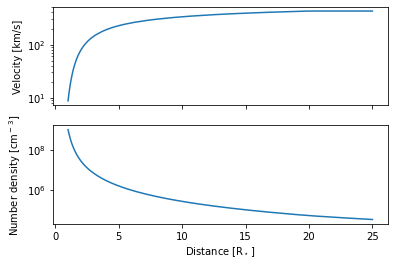

In [4]:
iso_cor = isothermal_solution.Isothermal_Corona(star=sun, mean_mol_weight=0.6, T0=2e6*un.K, n0=1e9/un.cm**3, B0=10*G, r_res=3_000, r_max=25*un.R_sun)
iso_cor.calc_wind_solution(alf_dist=20*const.R_sun, prec=1e-4)
iso_cor.plot(['velocity', 'number_density'])

## Polytropic solutions

As with the `Isothermal_Corona` class, the `Polytropic_Corona` does not have any required arguments, but defaults to EK Draconis values, as well as a polytropic index of 1.1. The precision of the solution can be set with `prec_vel`. If it doesn't reach this precision after reaching max_iter, then it takes the closest value--- forcing a higher precision should also generally be accompanied with a larger `max_iter`.

/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 0, 'Distance [$R_\\star$]')

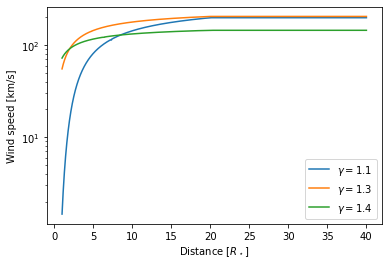

In [5]:
poly_idxs = [1.1, 1.3, 1.4]
poly_sols = []
fig, axs = plt.subplots()
for p in poly_idxs:
    poly_cor = polytropic_solution.Polytropic_Corona(poly_idx=p, star=sun, mean_mol_weight=0.6, T0=2e6*un.K, n0=1e9/un.cm**3, r_res=3000, B0=10*G)
    poly_cor.calc_wind_solution(alf_dist=20*const.R_sun, max_iter=1000, prec_vel=1*un.km/un.s)
    axs.plot(poly_cor.r_vec.cgs/poly_cor.star.R_star.cgs, poly_cor.velocity_profile.to('km/s'), label = rf"$\gamma=${p}")
    poly_sols.append(poly_cor)
axs.legend()
axs.set_yscale('log')
axs.set_ylabel("Wind speed [km/s]")
axs.set_xlabel(r"Distance [$R_\star$]")

## Bursts in the isothermal wind

Required inputs for a `burst` instance are the burst type ('ii' or 'iii') and an instance of the corona/wind solution. Both isothermal and polytropic winds are accepted, but here I just focus on the isothermal wind

In [6]:
typeii = bursts.Burst(iso_cor, 'ii', vb=700*un.km/un.s)
typeiii = bursts.Burst(iso_cor, 'iii') # default vb for type iii burst is 0.5c

The main functions of the `burst` class are `make_dynamic_spectrum` and `make_frequency_profile`. There are no required arguments for these, but there is control over the time and frequency range and resolution. The dynamic spectrum can be easily plot with `plot_dyn_spec`  

In [7]:
typeii.make_dynamic_spectrum(nu_min=10*un.MHz, nu_max=100*un.MHz, nu_res=0.1*un.MHz, duration=120*un.min, t_res=2*un.s)

In [8]:
typeiii.make_dynamic_spectrum(nu_min=10*un.MHz, nu_max=100*un.MHz, nu_res=0.5*un.MHz, duration=2*un.min, t_res=0.1*un.s)

(<Figure size 432x288 with 1 Axes>,
 <AxesSubplot:xlabel='Time since flare onset [min]', ylabel='Frequency [MHz]'>)

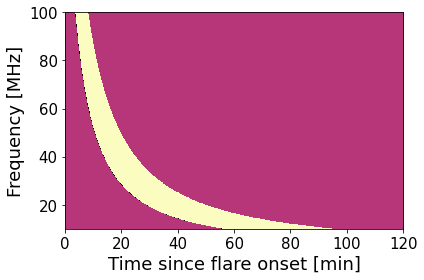

In [9]:
typeii.plot_dyn_spec()

Regions of black in the preceding plot indicate where the CME is slower than the Alfv\'en speed in the frame of the wind

(<Figure size 432x288 with 1 Axes>,
 <AxesSubplot:xlabel='Time since flare onset [min]', ylabel='Frequency [MHz]'>)

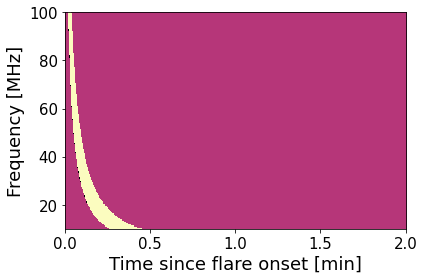

In [10]:
typeiii.plot_dyn_spec()

### Get de-dispersion parameters of the type III burst

Text(0, 0.5, 'Frequency [MHz]')

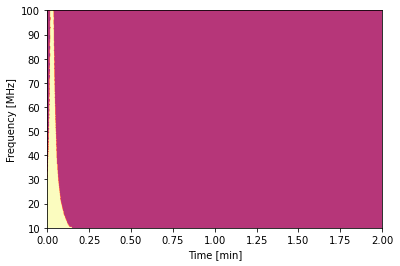

In [11]:
import copy
typeiii.make_frequency_profile(t_res=0.1*un.s, duration=2*un.min)
typeiii.fit_drift_rate(freq_range=(10,100)) #only fit in the range from 10--100 MHz. Not a required argument
de_disp = typeiii.dedisperse()

extents = copy.deepcopy(typeiii.extents)
extents[0] = extents[0].to('min').value
extents[1] = extents[1].to('min').value
extents[2] = extents[2].to('MHz').value
extents[3] = extents[3].to('MHz').value

plt.imshow(de_disp, aspect='auto', origin='lower', extent=extents, cmap='magma')
plt.xlabel("Time [min]")
plt.ylabel("Frequency [MHz]")

It is worth being mindful that the quality of the dynamic spectrum, frequency profile, and de-dispersion depend on the speed of the beam and the spatial resolution of the wind solution---if the spatial resolution is too coarse for a given beam speed and time resolution, then the beam may hang out in a single spatial element for many itnegrations and return funky solutions 